In [1]:
import pandas as pd
import numpy as np

file_path = 'Lung Cancer Dataset.csv'
df = pd.read_csv(file_path)

print("--- 1. Kiểm tra dữ liệu ban đầu ---")
print(f"Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("Số lượng giá trị bị khuyết :", df.isnull().sum().sum())

df['PULMONARY_DISEASE_NUM'] = df['PULMONARY_DISEASE'].map({'YES': 1, 'NO': 0})

print("\n--- 2. Kiểm tra chỉ số bất thường  ---")
print("Độ bão hòa Oxy (Min - Max):", df['OXYGEN_SATURATION'].min(), "-", df['OXYGEN_SATURATION'].max())
print("Độ tuổi (Min - Max):", df['AGE'].min(), "-", df['AGE'].max())

binary_cols = [
    'GENDER', 'SMOKING', 'FINGER_DISCOLORATION', 'MENTAL_STRESS', 
    'EXPOSURE_TO_POLLUTION', 'LONG_TERM_ILLNESS', 'IMMUNE_WEAKNESS', 
    'BREATHING_ISSUE', 'ALCOHOL_CONSUMPTION', 'THROAT_DISCOMFORT', 
    'CHEST_TIGHTNESS', 'FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY', 'STRESS_IMMUNE'
]
df[binary_cols] = df[binary_cols].astype(int)

print("\n5 dòng đầu tiên:")
print(df[['AGE', 'SMOKING', 'OXYGEN_SATURATION', 'PULMONARY_DISEASE', 'PULMONARY_DISEASE_NUM']].head())

--- 1. Kiểm tra dữ liệu ban đầu ---
Kích thước tập dữ liệu: 5000 dòng, 18 cột
Số lượng giá trị bị khuyết : 0

--- 2. Kiểm tra chỉ số bất thường  ---
Độ bão hòa Oxy (Min - Max): 89.92313261633554 - 99.7957863279692
Độ tuổi (Min - Max): 30 - 84

5 dòng đầu tiên:
   AGE  SMOKING  OXYGEN_SATURATION PULMONARY_DISEASE  PULMONARY_DISEASE_NUM
0   68        1          95.977287                NO                      0
1   81        1          97.184483               YES                      1
2   58        1          94.974939                NO                      0
3   44        1          95.187900               YES                      1
4   72        1          93.503008               YES                      1


BƯỚC 3: PHÂN TÍCH DỮ LIỆU 

--- 1. Tỷ lệ phân bố bệnh nhân ---
                   Số lượng  Tỷ lệ (%)
PULMONARY_DISEASE                     
NO                     2963      59.26
YES                    2037      40.74


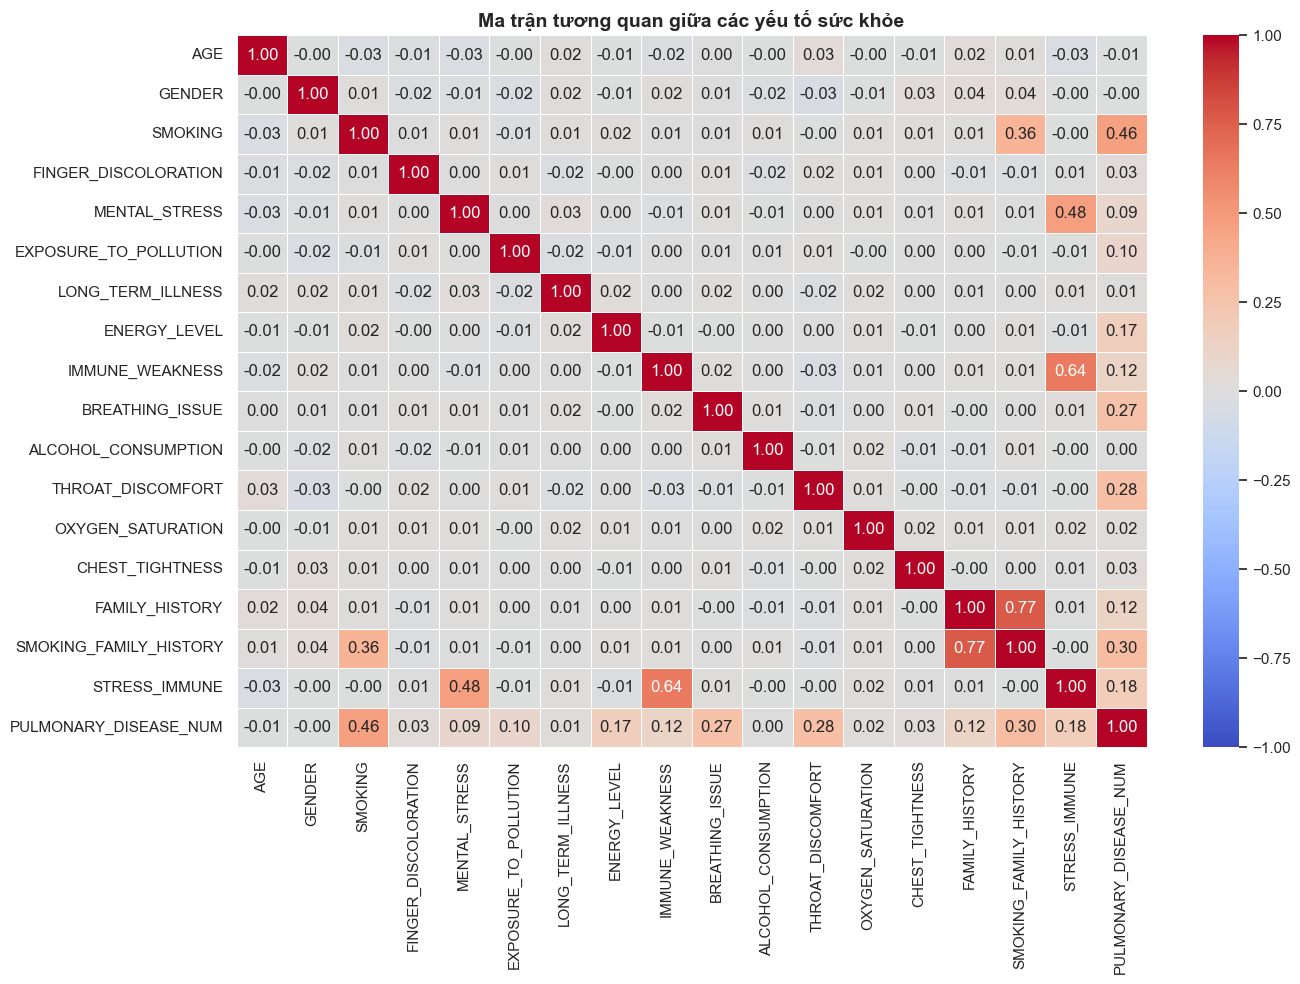

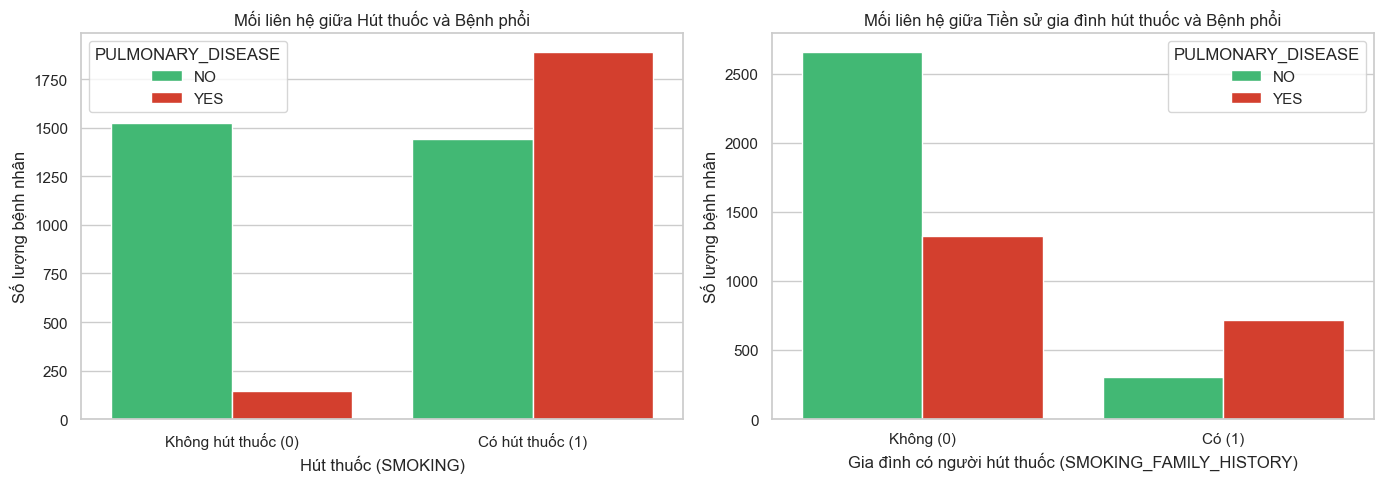

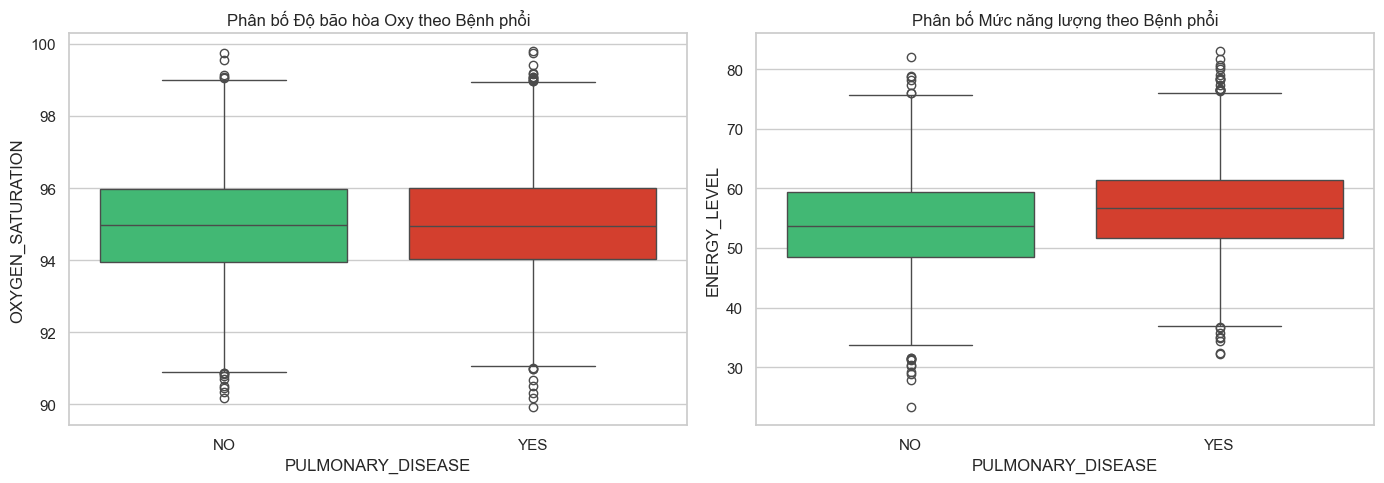

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Lung Cancer Dataset.csv')
df['PULMONARY_DISEASE_NUM'] = df['PULMONARY_DISEASE'].map({'YES': 1, 'NO': 0})

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*50)
print("BƯỚC 3: PHÂN TÍCH DỮ LIỆU ")
print("="*50)

disease_counts = df['PULMONARY_DISEASE'].value_counts()
disease_pct = df['PULMONARY_DISEASE'].value_counts(normalize=True) * 100

print("\n--- 1. Tỷ lệ phân bố bệnh nhân ---")
print(pd.DataFrame({'Số lượng': disease_counts, 'Tỷ lệ (%)': disease_pct.round(2)}))

plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan giữa các yếu tố sức khỏe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

custom_palette = {'NO': '#2ecc71', 'YES': "#ee2913"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='SMOKING', hue='PULMONARY_DISEASE', ax=axes[0], palette=custom_palette)
axes[0].set_title('Mối liên hệ giữa Hút thuốc và Bệnh phổi')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Không hút thuốc (0)', 'Có hút thuốc (1)'])
axes[0].set_xlabel('Hút thuốc (SMOKING)')
axes[0].set_ylabel('Số lượng bệnh nhân')

sns.countplot(data=df, x='SMOKING_FAMILY_HISTORY', hue='PULMONARY_DISEASE', ax=axes[1], palette=custom_palette)
axes[1].set_title('Mối liên hệ giữa Tiền sử gia đình hút thuốc và Bệnh phổi')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Không (0)', 'Có (1)'])
axes[1].set_xlabel('Gia đình có người hút thuốc (SMOKING_FAMILY_HISTORY)')
axes[1].set_ylabel('Số lượng bệnh nhân')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, 
    x='PULMONARY_DISEASE', 
    y='OXYGEN_SATURATION', 
    hue='PULMONARY_DISEASE',
    legend=False,           
    ax=axes[0], 
    palette=custom_palette
)
axes[0].set_title('Phân bố Độ bão hòa Oxy theo Bệnh phổi')

sns.boxplot(
    data=df, 
    x='PULMONARY_DISEASE', 
    y='ENERGY_LEVEL', 
    hue='PULMONARY_DISEASE',
    legend=False,
    ax=axes[1], 
    palette=custom_palette
)
axes[1].set_title('Phân bố Mức năng lượng theo Bệnh phổi')

plt.tight_layout()
plt.show()

In [3]:
print("="*50)
print("BƯỚC 4: FEATURE ENGINEERING")
print("="*50)

df_fe = df.copy()

df_fe['TOTAL_SMOKE_RISK'] = df_fe['SMOKING'] + df_fe['SMOKING_FAMILY_HISTORY'] + df_fe['EXPOSURE_TO_POLLUTION']

df_fe['TOTAL_RESPIRATORY_SYMPTOMS'] = df_fe['BREATHING_ISSUE'] + df_fe['THROAT_DISCOMFORT'] + df_fe['CHEST_TIGHTNESS']

df_fe['IMMUNE_STRESS_SCORE'] = df_fe['IMMUNE_WEAKNESS'] + df_fe['MENTAL_STRESS'] + df_fe['STRESS_IMMUNE']

X = df_fe.drop(columns=['PULMONARY_DISEASE', 'PULMONARY_DISEASE_NUM'])
y = df_fe['PULMONARY_DISEASE_NUM']

print(f"-> Số lượng đặc trưng đầu vào sau khi Feature Engineering: {X.shape[1]} cột")
print("\nDanh sách 5 dòng đầu tiên của các đặc trưng mới được tạo:")
print(X[['TOTAL_SMOKE_RISK', 'TOTAL_RESPIRATORY_SYMPTOMS', 'IMMUNE_STRESS_SCORE']].head())

BƯỚC 4: FEATURE ENGINEERING
-> Số lượng đặc trưng đầu vào sau khi Feature Engineering: 20 cột

Danh sách 5 dòng đầu tiên của các đặc trưng mới được tạo:
   TOTAL_SMOKE_RISK  TOTAL_RESPIRATORY_SYMPTOMS  IMMUNE_STRESS_SCORE
0                 2                           2                    1
1                 2                           2                    1
2                 1                           1                    0
3                 2                           2                    1
4                 2                           2                    1


In [4]:
from sklearn.model_selection import train_test_split

print("="*50)
print("BƯỚC 5: CHIA DỮ LIỆU TRAIN / TEST")
print("="*50)

# 1. Tách Feature (X) và Target (y)
# X: loại bỏ cột nhãn gốc và cột nhãn số
X = df.drop(columns=['PULMONARY_DISEASE', 'PULMONARY_DISEASE_NUM'])
y = df['PULMONARY_DISEASE_NUM']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Tổng số mẫu dữ liệu: {len(df)}")
print(f"-> Tập Train (80%): {X_train.shape[0]} mẫu, {X_train.shape[1]} thuộc tính")
print(f"-> Tập Test  (20%): {X_test.shape[0]} mẫu, {X_test.shape[1]} thuộc tính")

print("\nTỷ lệ nhãn trong tập Train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2).to_dict())

print("Tỷ lệ nhãn trong tập Test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2).to_dict())

BƯỚC 5: CHIA DỮ LIỆU TRAIN / TEST
Tổng số mẫu dữ liệu: 5000
-> Tập Train (80%): 4000 mẫu, 17 thuộc tính
-> Tập Test  (20%): 1000 mẫu, 17 thuộc tính

Tỷ lệ nhãn trong tập Train (%):
{0: 59.25, 1: 40.75}
Tỷ lệ nhãn trong tập Test (%):
{0: 59.3, 1: 40.7}


In [ ]:
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*60)
print("HUẤN LUYỆN VÀ ĐÁNH GIÁ TỔNG HỢP CÁC MÔ HÌNH")
print("="*60)

models_dict = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
}

results = []

# 2. Huấn luyện và đánh giá từng mô hình
for name, model in models_dict.items():

    # Huấn luyện mô hình
    model.fit(X_train, y_train)

    # Dự đoán nhãn và xác suất
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Mô hình': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision (%)': round(prec * 100, 2),
        'Recall (%)': round(rec * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2),
        'AUC': round(auc, 4)
    })

# 3. Hiển thị bảng kết quả
df_results = pd.DataFrame(results)
print("\n--- BẢNG KẾT QUẢ HIỆU NĂNG CÁC MÔ HÌNH ---")
print(df_results.to_string(index=False))

HUẤN LUYỆN VÀ ĐÁNH GIÁ TỔNG HỢP CÁC MÔ HÌNH

--- BẢNG KẾT QUẢ HIỆU NĂNG CÁC MÔ HÌNH ---
            Mô hình  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)    AUC
Logistic Regression          88.8          85.04       87.96         86.47 0.9260
      Decision Tree          80.5          76.24       75.68         75.96 0.7974
            XGBoost          90.4          88.40       87.96         88.18 0.9139
           LightGBM          90.1          88.12       87.47         87.79 0.9167


BƯỚC 7: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST

--- KẾT QUẢ HIỆU NĂNG  ---
Accuracy  (Độ chính xác tổng thể) : 90.40%
Precision (Độ chính xác lớp bệnh) : 88.97%
Recall    (Độ nhạy / Phát hiện bệnh): 87.22%
F1-Score  (Trung bình điều hòa)    : 88.09%

--- BÁO CÁO CHI TIẾT  ---
                precision    recall  f1-score   support

Không bệnh (0)       0.91      0.93      0.92       593
   Có bệnh (1)       0.89      0.87      0.88       407

      accuracy                           0.90      1000
     macro avg       0.90      0.90      0.90      1000
  weighted avg       0.90      0.90      0.90      1000



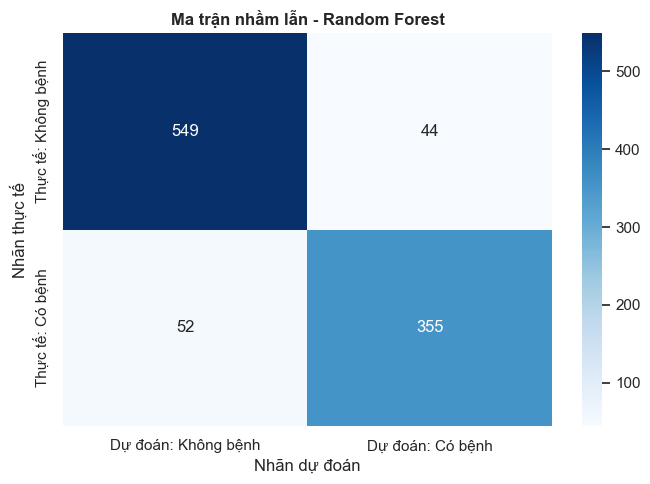

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix
)

print("="*50)
print("BƯỚC 7: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n--- KẾT QUẢ HIỆU NĂNG  ---")
print(f"Accuracy  (Độ chính xác tổng thể) : {acc_rf*100:.2f}%")
print(f"Precision (Độ chính xác lớp bệnh) : {prec_rf*100:.2f}%")
print(f"Recall    (Độ nhạy / Phát hiện bệnh): {rec_rf*100:.2f}%")
print(f"F1-Score  (Trung bình điều hòa)    : {f1_rf*100:.2f}%")

print("\n--- BÁO CÁO CHI TIẾT  ---")
print(classification_report(y_test, y_pred_rf, target_names=['Không bệnh (0)', 'Có bệnh (1)']))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán: Không bệnh', 'Dự đoán: Có bệnh'],
            yticklabels=['Thực tế: Không bệnh', 'Thực tế: Có bệnh'])
plt.title('Ma trận nhầm lẫn - Random Forest', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

In [13]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*60)
print("BƯỚC 8: TỐI ƯU HÓA SIÊU THAM SỐ")
print("="*60)

start_time = time.time()

param_grid = {
    'n_estimators': [50, 100, 200],         
    'max_depth': [None, 10, 20],           
    'min_samples_split': [2, 5],            
    'min_samples_leaf': [1, 2],          
    'criterion': ['gini', 'entropy']        
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5,                   
    scoring='f1',          
    n_jobs=-1,           
    verbose=1
)

grid_search.fit(X_train, y_train)

end_time = time.time()

print(f"\n Thời gian hoàn thành Grid Search: {end_time - start_time:.2f} giây")
print("\n Bộ siêu tham số tối ưu nhất :")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

acc_opt = accuracy_score(y_test, y_pred_best)
prec_opt = precision_score(y_test, y_pred_best)
rec_opt = recall_score(y_test, y_pred_best)
f1_opt = f1_score(y_test, y_pred_best)
auc_opt = roc_auc_score(y_test, y_prob_best)

print("\n--- HIỆU NĂNG MÔ HÌNH RANDOM FOREST SAU KHI TỐI ƯU ---")
print(f"Accuracy   : {acc_opt*100:.2f}%")
print(f"Precision  : {prec_opt*100:.2f}%")
print(f"Recall     : {rec_opt*100:.2f}%")
print(f"F1-Score   : {f1_opt*100:.2f}%")
print(f"AUC        : {auc_opt:.4f}")

BƯỚC 8: TỐI ƯU HÓA SIÊU THAM SỐ
Fitting 5 folds for each of 72 candidates, totalling 360 fits

 Thời gian hoàn thành Grid Search: 32.61 giây

 Bộ siêu tham số tối ưu nhất :
  - criterion: entropy
  - max_depth: 10
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 100

--- HIỆU NĂNG MÔ HÌNH RANDOM FOREST SAU KHI TỐI ƯU ---
Accuracy   : 90.60%
Precision  : 88.45%
Recall     : 88.45%
F1-Score   : 88.45%
AUC        : 0.9232


In [ ]:
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*60)
print("BƯỚC 10: BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP CÁC MÔ HÌNH")
print("="*60)

lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
dt_model = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

models_dict = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'Random Forest': best_rf
}

comparison_results = []

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = round(accuracy_score(y_test, y_pred) * 100, 2)
    prec = round(precision_score(y_test, y_pred) * 100, 2)
    rec = round(recall_score(y_test, y_pred) * 100, 2)
    f1 = round(f1_score(y_test, y_pred) * 100, 2)
    auc_val = round(roc_auc_score(y_test, y_prob), 4)
    
    comparison_results.append({
        'Mô hình': name,
        'Accuracy (%)': acc,
        'Precision (%)': prec,
        'Recall (%)': rec,
        'F1-Score (%)': f1,
        'AUC': auc_val
    })

df_compare = pd.DataFrame(comparison_results)
print("\n--- BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG THỰC NGHIỆM ---")
print(df_compare.to_string(index=False))

BƯỚC 10: BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP CÁC MÔ HÌNH

--- BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG THỰC NGHIỆM ---
            Mô hình  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)    AUC
Logistic Regression          88.8          85.04       87.96         86.47 0.9260
      Decision Tree          80.5          76.24       75.68         75.96 0.7974
            XGBoost          90.4          88.40       87.96         88.18 0.9139
           LightGBM          90.1          88.12       87.47         87.79 0.9167
      Random Forest          90.6          88.45       88.45         88.45 0.9232
